# L'Unione fa la forza!


Abbiamo visto in precedenza che è possibile creare dei modelli con gli alberi di decisione (Decision Tree) che sono in grado di fare classificazione o regressione.
Hanno il vantaggio di essere "semplici" e "interpretabili".

Il problema è che spesso le performance non sono così elevate e spesso per aumentare le performance si ricade nel problema dell'overfitting



## 1. Introduzione all'Ensemble Learning: Insiemi di Modelli — Bagging vs Boosting

In questa lezione esploreremo le due tecniche principali di **Ensemble Learning**: il Bagging e il Boosting. L'idea alla base di entrambi è semplice: "L'unione fa la forza". Invece di usare un solo modello predittivo, ne usiamo molti e combiniamo i loro risultati.


Vediamo di capire cosa si intende per **Ensemble**

Un "Ensemble" è un gruppo di modelli (spesso chiamati *weak learners*, ovvero apprenditori deboli) che lavorano insieme per risolvere lo stesso problema. L'obiettivo è migliorare le performance riducendo i due nemici principali del Machine Learning:

* **Varianza** (Overfitting: il modello è troppo sensibile ai dati di addestramento).
* **Bias** (Underfitting: il modello è troppo semplice per catturare la complessità dei dati).

---

## Bagging (Bootstrap Aggregating)

Il Bagging mira a ridurre la **varianza**. Funziona creando diversi sotto-insieme di dati estratti casualmente dal dataset originale (con ripetizione).

### Come funziona:

1. **Bootstrap**: Si creano  campioni casuali dal dataset originale.
2. **Parallelismo**: Si addestra un modello indipendente su ogni campione.
3. **Aggregazione**: Per la classificazione si usa la maggioranza, per la regressione la media.

**L'esempio classico:** Il **Random Forest**. In questo modello, molti alberi di decisione vengono addestrati in parallelo e il risultato finale è la media dei loro voti.

---

## 3. Boosting

Il Boosting mira a ridurre il **bias** e la varianza. A differenza del Bagging, i modelli non sono indipendenti, ma vengono addestrati in **sequenza**.

### Come funziona:

1. Si addestra un primo modello sui dati.
2. Si analizzano gli errori commessi dal primo modello.
3. Si addestra un secondo modello dando **più importanza (peso)** ai dati che il primo ha sbagliato.
4. Si ripete il processo: ogni nuovo modello cerca di correggere i "colleghi" precedenti.

**Gli esempi classici:** AdaBoost, Gradient Boosting, XGBoost.

---

## 4. Confronto Rapido

| Caratteristica | Bagging | Boosting |
| --- | --- | --- |
| **Obiettivo principale** | Ridurre la Varianza (Overfitting) | Ridurre il Bias (Underfitting) |
| **Ordine di addestramento** | Parallelo | Sequenziale |
| **Relazione tra i modelli** | Indipendenti | Ogni modello corregge il precedente |
| **Esempio tipico** | Random Forest | Gradient Boosting / XGBoost |

---



Accuratezza del modello Decision Tre: 0.9096
Accuratezza media Bagging (Random Forest): 0.9497
Accuratezza media Boosting (Gradient Boosting): 0.9548


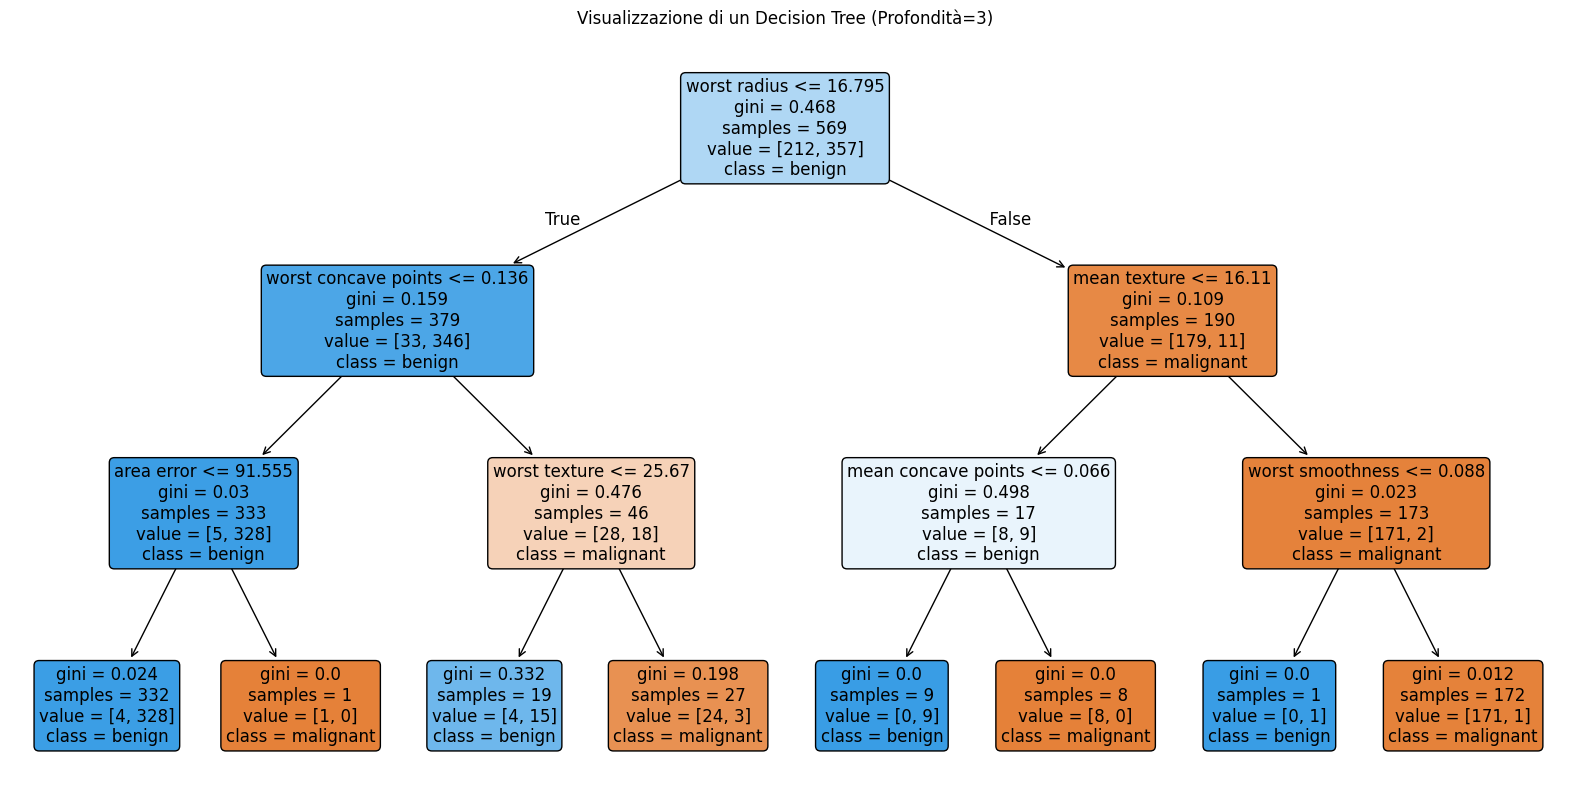

In [ ]:
# Esempio di implementazione in python

# Importo le librerie
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import plot_tree

# 1. Caricamento dati
data = load_breast_cancer() # esempio di dataset
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Definiamo i modelli
# Bagging (Random Forest)
bagging_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Boosting (Gradient Boosting)
boosting_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

tree_model = DecisionTreeClassifier(random_state=42)

# 3. Valutazione
bagging_scores = cross_val_score(bagging_model, X_train, y_train, cv=5)
boosting_scores = cross_val_score(boosting_model, X_train, y_train, cv=5)
tree_scores = cross_val_score(tree_model, X_train, y_train, cv=5)

# 4. Stampa dei risultati
print(f"Accuratezza del modello Decision Tre: {tree_scores.mean():.4f}")
print(f"Accuratezza media Bagging (Random Forest): {bagging_scores.mean():.4f}")
print(f"Accuratezza media Boosting (Gradient Boosting): {boosting_scores.mean():.4f}")


# Qui esempio di "albero di decisioni piccolo per fare plot"

small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(X, y)

# 2. Creazione del grafico
plt.figure(figsize=(20, 10))
plot_tree(small_tree,
          feature_names=data.feature_names,  # Nomi delle caratteristiche (es. mean radius)
          class_names=data.target_names,     # Nomi delle classi (malignant, benign)
          filled=True,                       # Colora i nodi in base alla classe
          rounded=True,                      # Arrotonda gli angoli dei box
          fontsize=12)

plt.title("Visualizzazione di un Decision Tree (Profondità=3)")
plt.show()

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ==========================
#  TRAIN / TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,      # manteniamo proporzione classi nel test
    random_state=42
)

# ==========================
#  DEFINIZIONE MODELLI
# ==========================

tree_model = DecisionTreeClassifier(random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# ==========================
# CROSS VALIDATION SOLO SUL TRAIN
# ==========================

tree_cv_scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Decision Tree CV AUC:", tree_cv_scores.mean())
print("Random Forest CV AUC:", rf_cv_scores.mean())

# ==========================
#  FIT FINALE SUL TRAIN
# ==========================

tree_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# ==========================
#  VALUTAZIONE SU TEST SET
# ==========================

tree_pred = tree_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

tree_proba = tree_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n--- TEST PERFORMANCE ---")

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("AUC:", roc_auc_score(y_test, tree_proba))
print(classification_report(y_test, tree_pred))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("AUC:", roc_auc_score(y_test, rf_proba))
print(classification_report(y_test, rf_pred))

Decision Tree CV AUC: 0.9031475748194013
Random Forest CV AUC: 0.9875128998968007

--- TEST PERFORMANCE ---

Decision Tree
Accuracy: 0.9122807017543859
AUC: 0.9156746031746031
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


Random Forest
Accuracy: 0.956140350877193
AUC: 0.9937169312169312
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Decision Tree CV AUC: 0.9031475748194013
Random Forest CV AUC: 0.987358101135191

==================== Decision Tree ====================
Accuracy: 0.9122807017543859
AUC: 0.9156746031746031
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

Confusion Matrix:
 [[39  3]
 [ 7 65]]


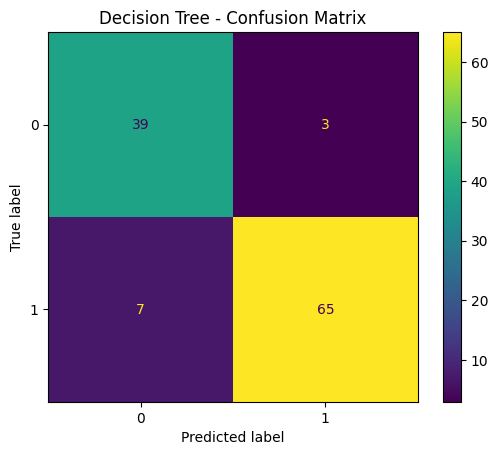

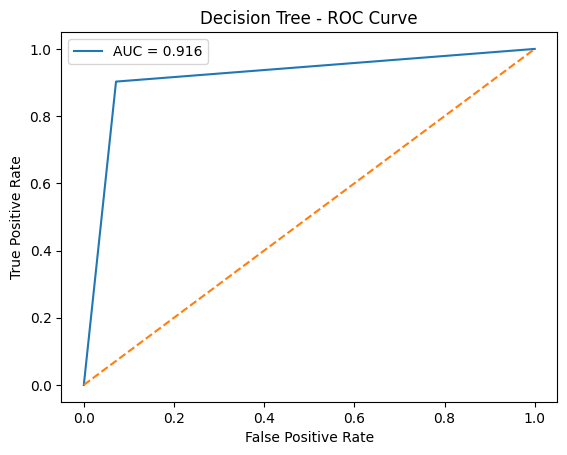

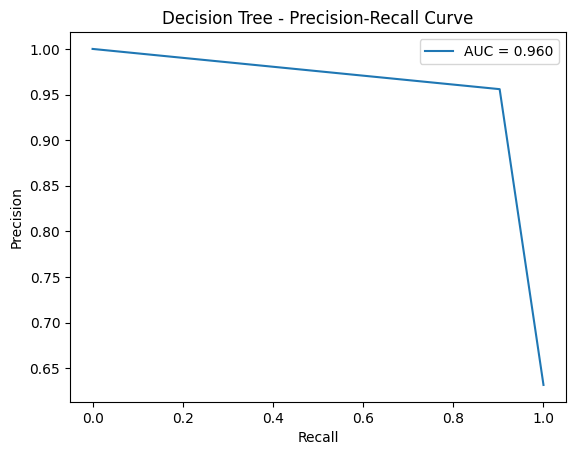


==================== Random Forest ====================
Accuracy: 0.956140350877193
AUC: 0.9930555555555556
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
 [[39  3]
 [ 2 70]]


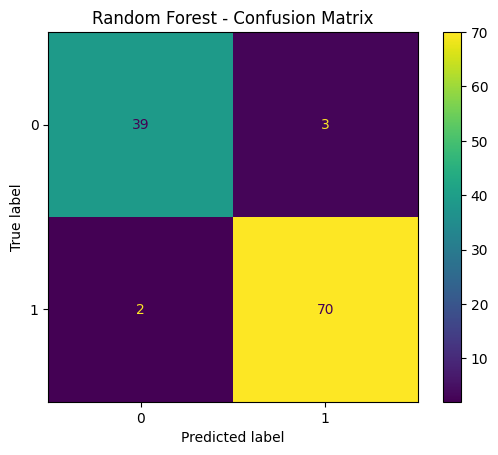

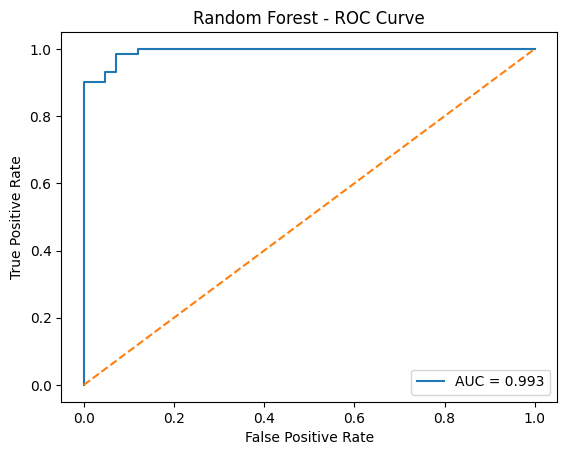

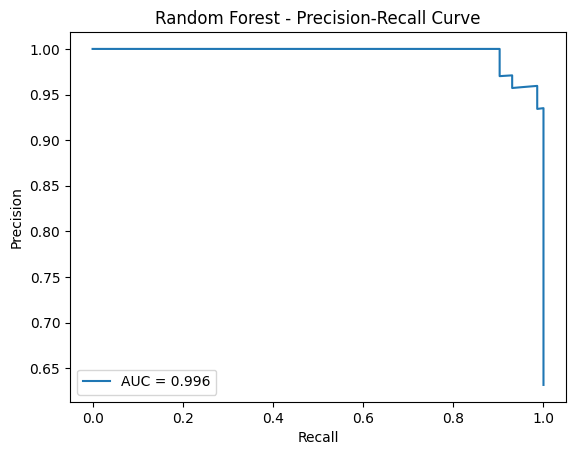

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

# ==========================
# TRAIN / TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==========================
# MODELLI
# ==========================

tree_model = DecisionTreeClassifier(random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# ==========================
#  CROSS VALIDATION
# ==========================

tree_cv_scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Decision Tree CV AUC:", tree_cv_scores.mean())
print("Random Forest CV AUC:", rf_cv_scores.mean())

# ==========================
#  FIT FINALE
# ==========================

tree_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# ==========================
# 5️ PREDIZIONI
# ==========================

models = {
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

for name, model in models.items():

    print(f"\n==================== {name} ====================")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))

    # ==========================
    #  Confusion Matrix
    # ==========================

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    # ==========================
    # ROC Curve
    # ==========================

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.show()

    # ==========================
    # Precision-Recall Curve
    # ==========================

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    plt.figure()
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{name} - Precision-Recall Curve")
    plt.legend()
    plt.show()

In [10]:
# come installare libreria per scaricare dataset di esempio...

!pip install ucimlrepo

In [11]:
# esempio di codice per utilizzare i dataset contenuti in questo sito:
# https://archive.ics.uci.edu/

from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

#  Bootstrap: Campionamento da una Distribuzione

In questo paragrafo vediamo di introdurre in modo leggermente più approfondito il bootstrap che è collegato, come abbiamo visto, con il Bagging.

##  Il Problema del Campionamento

In statistica e machine learning, spesso abbiamo a disposizione un **campione osservato** di $n$ osservazioni:

$$\mathcal{D} = \{x_1, x_2, \ldots, x_n\}$$

estratto da una distribuzione sconosciuta $P$. Vogliamo stimare proprietà di $P$ (media, varianza, distribuzione di uno stimatore), ma abbiamo **un solo campione** e non possiamo raccogliere nuovi dati.

**Domanda:** Come possiamo quantificare l'incertezza delle nostre stime?

---

## L'Idea del Bootstrap

Il **Bootstrap** venne ideato dal nostro statistico Efron nel 1979 e  risponde a questa domanda con un'idea elegante:

> *"Se non possiamo campionare di nuovo dalla vera distribuzione $P$, campioniamo dalla distribuzione empirica $\hat{P}_n$, che è la migliore approssimazione di $P$ che abbiamo."*

La **distribuzione empirica** $\hat{P}_n$ assegna probabilità $\frac{1}{n}$ a ciascuna delle $n$ osservazioni del campione originale:

$$\hat{P}_n(x) = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}[x_i = x]$$

Campionare da $\hat{P}_n$ equivale a **estrarre con reinserimento** dal campione originale.

IMPORTANTE: è una estrazione con reinserimento.. un po' come giocare a tombola rimettendo nel sacchetto i numeri usciti.

---

##  Procedura Bootstrap — Algoritmo Formale

Dato il campione originale $\mathcal{D} = \{x_1, \ldots, x_n\}$ e un numero di repliche $B$:

$$\boxed{
\text{Per } b = 1, 2, \ldots, B:
}$$

**Step 1:** Genera un *campione bootstrap* $\mathcal{D}^{*(b)}$ estraendo **$n$ osservazioni con reinserimento** da $\mathcal{D}$:

$$\mathcal{D}^{*(b)} = \{x_1^{*(b)}, x_2^{*(b)}, \ldots, x_n^{*(b)}\}, \quad x_i^{*(b)} \sim \hat{P}_n$$

Ogni $x_i^{*(b)}$ è scelto uniformemente a caso tra $\{x_1, \ldots, x_n\}$, indipendentemente.

**Step 2:** Calcola la statistica di interesse $\hat{\theta}^{*(b)}$ sul campione bootstrap:

$$\hat{\theta}^{*(b)} = s(\mathcal{D}^{*(b)})$$

dove $s(\cdot)$ è una funzione arbitraria (media, mediana, coefficiente di regressione, errore di un modello, ...).

**Step 3:** Al termine dei $B$ cicli, si dispone della **distribuzione bootstrap**:

$$\{\hat{\theta}^{*(1)}, \hat{\theta}^{*(2)}, \ldots, \hat{\theta}^{*(B)}\}$$

---

## Proprietà Chiave: Campionamento con Reinserimento

Poiché ogni estrazione è **con reinserimento**, in ogni campione bootstrap $\mathcal{D}^{*(b)}$:

- alcune osservazioni originali appariranno **più di una volta**
- alcune osservazioni originali **non appariranno affatto**

**Quante osservazioni originali appaiono mediamente?**

La probabilità che una specifica osservazione $x_i$ **non venga selezionata** in nessuna delle $n$ estrazioni è:

$$P(x_i \notin \mathcal{D}^{*(b)}) = \left(1 - \frac{1}{n}\right)^n \xrightarrow{n \to \infty} e^{-1} \approx 0.368$$

Quindi, mediamente, ogni campione bootstrap contiene circa il $\mathbf{63.2\%}$ delle osservazioni originali distinte. Il restante $\sim 36.8\%$ viene chiamato **Out-of-Bag (OOB)** — e questa proprietà sarà fondamentale per il Bagging.

---

##  (CENNI) Utilizzi del Bootstrap nella statistica

Qui di seguito presentiamo i principali utilizzi del Boostrap.

###  Stima della Varianza di uno Stimatore

La varianza bootstrap di $\hat{\theta}$ è:

$$\widehat{\text{Var}}_{\text{boot}}(\hat{\theta}) = \frac{1}{B-1} \sum_{b=1}^{B} \left(\hat{\theta}^{*(b)} - \bar{\theta}^*\right)^2$$

dove $\bar{\theta}^* = \frac{1}{B} \sum_{b=1}^{B} \hat{\theta}^{*(b)}$ è la media delle stime bootstrap.

###  (CENNI) Intervalli di Confidenza Bootstrap

Un intervallo di confidenza al $(1-\alpha)\%$ si ottiene dai quantili della distribuzione bootstrap:

$$IC_{1-\alpha} = \left[\hat{\theta}^*_{\alpha/2},\; \hat{\theta}^*_{1-\alpha/2}\right]$$

dove $\hat{\theta}^*_{\alpha/2}$ e $\hat{\theta}^*_{1-\alpha/2}$ sono i quantili di livello $\alpha/2$ e $1-\alpha/2$ della distribuzione $\{\hat{\theta}^{*(b)}\}_{b=1}^B$.

###  Riduzione della Varianza (anticipazione del Bagging)

Invece di usare un singolo stimatore $\hat{\theta}$ calcolato su $\mathcal{D}$, possiamo **aggregare** le $B$ stime bootstrap:

$$\hat{\theta}_{\text{bag}} = \frac{1}{B} \sum_{b=1}^{B} \hat{\theta}^{*(b)}$$

Questa media ha varianza ridotta rispetto al singolo stimatore:

$$\text{Var}\left(\hat{\theta}_{\text{bag}}\right) \approx \frac{\text{Var}(\hat{\theta})}{B}$$

Questa è esattamente l'idea alla base del **Bagging (Bootstrap Aggregating)**, che approfondiremo nella prossima sezione.

---

##  Esempio Numerico: Bootstrap sulla Media

Supponiamo di avere il campione $\mathcal{D} = \{2, 4, 6, 8, 10\}$ ($n=5$) e vogliamo stimare la media $\mu$.

La media campionaria osservata è:
$$\hat{\mu} = \frac{2+4+6+8+10}{5} = 6$$

**Tre campioni bootstrap** (con reinserimento):

| Campione Bootstrap | Valori estratti | $\hat{\mu}^*$ |
|---|---|---|
| $\mathcal{D}^{*(1)}$ | $\{4, 4, 2, 10, 6\}$ | $5.2$ |
| $\mathcal{D}^{*(2)}$ | $\{8, 8, 6, 2, 10\}$ | $6.8$ |
| $\mathcal{D}^{*(3)}$ | $\{6, 10, 10, 4, 6\}$ | $7.2$ |

La distribuzione bootstrap $\{5.2, 6.8, 7.2, \ldots\}$ (su $B$ repliche) ci dà una stima dell'incertezza attorno a $\hat{\mu} = 6$.

---



#  Bagging: Bootstrap Aggregating

Riprendiamo quanto spiegato in precedenza e ripartiamo dal "problema della varianza" nei Modelli di ML.

Per ulteriori approfondimenti dei passaggi matematici puoi vedere qui (per esempio):
https://it.wikipedia.org/wiki/Compromesso_bias-varianza


Molti modelli di Machine Learning potenti — in particolare gli **alberi decisionali** — soffrono di **alta varianza**: sono estremamente sensibili ai dati di training e tendono all'overfitting.

Formalmente, l'errore atteso di un modello $\hat{f}$ su un nuovo punto $x$ si decompone come:

$$\mathbb{E}\left[(y - \hat{f}(x))^2\right] = \underbrace{\text{Bias}^2(\hat{f}(x))}_{\text{errore sistematico}} + \underbrace{\text{Var}(\hat{f}(x))}_{\text{sensibilità ai dati}} + \underbrace{\sigma^2_\epsilon}_{\text{rumore irriducibile}}$$

Un albero decisionale profondo ha:
- **Bias basso**  (si adatta bene ai dati)
- **Varianza alta**  (cambia molto al variare del training set)

**Obiettivo del Bagging:** ridurre la varianza senza aumentare il bias.

---

## L'Idea Fondamentale: Media di Stimatori Indipendenti

**Proprietà statistica chiave:** Se $\hat{f}_1, \hat{f}_2, \ldots, \hat{f}_B$ sono $B$ modelli **indipendenti e identicamente distribuiti**, ciascuno con varianza $\sigma^2$, allora la loro media:

$$\bar{f}(x) = \frac{1}{B} \sum_{b=1}^{B} \hat{f}_b(x)$$

ha varianza:

$$\text{Var}(\bar{f}(x)) = \frac{\sigma^2}{B}$$

Aumentando $B$, la varianza **tende a zero**! Il problema è che nella realtà abbiamo **un solo dataset** $\mathcal{D}$, e non possiamo addestrare $B$ modelli su $B$ dataset indipendenti.

**Soluzione:** usare il **Bootstrap** per simulare $B$ dataset diversi.

---

## Bagging: Algoritmo Formale

Dato il dataset originale $\mathcal{D} = \{(x_1, y_1), \ldots, (x_n, y_n)\}$, un learner base $\mathcal{A}$ e un numero di repliche $B$:

$$\boxed{\textbf{Fase 1 — Bootstrap (già vista):}}$$

Per $b = 1, 2, \ldots, B$, genera un campione bootstrap $\mathcal{D}^{*(b)}$ estraendo $n$ esempi **con reinserimento** da $\mathcal{D}$:

$$\mathcal{D}^{*(b)} = \{(x_1^{*(b)}, y_1^{*(b)}), \ldots, (x_n^{*(b)}, y_n^{*(b)})\}, \quad (x_i^{*(b)}, y_i^{*(b)}) \sim \hat{P}_n$$

$$\boxed{\textbf{Fase 2 — Training:}}$$

Addestra il learner base $\mathcal{A}$ su ogni campione bootstrap, ottenendo $B$ modelli:

$$\hat{f}^{*(b)} = \mathcal{A}(\mathcal{D}^{*(b)}), \quad b = 1, \ldots, B$$

$$\boxed{\textbf{Fase 3 — Aggregation:}}$$

Combina le predizioni dei $B$ modelli:

**Regressione** — media delle predizioni:
$$\hat{f}_{\text{bag}}(x) = \frac{1}{B} \sum_{b=1}^{B} \hat{f}^{*(b)}(x)$$

**Classificazione** — voto di maggioranza:
$$\hat{y}_{\text{bag}}(x) = \underset{c \in \mathcal{C}}{\arg\max} \sum_{b=1}^{B} \mathbf{1}\left[\hat{f}^{*(b)}(x) = c\right]$$

---

## (CENNI) Perché il Bootstrap Riduce la Varianza?

Qui cerchiamo di capire perché Bootstap riduce la varianza.


I modelli $\hat{f}^{*(b)}$ sono addestrati su campioni bootstrap **diversi ma dipendenti** (provengono tutti da $\mathcal{D}$). Non sono quindi i.i.d. — esiste una correlazione $\rho$ tra le loro predizioni.

La varianza dell'aggregazione è in realtà:

$$\text{Var}(\hat{f}_{\text{bag}}(x)) = \rho \cdot \sigma^2 + \frac{1-\rho}{B} \cdot \sigma^2$$

dove:
- $\rho \in [0,1]$ è la **correlazione media** tra coppie di modelli
- $\sigma^2 = \text{Var}(\hat{f}^{*(b)}(x))$ è la varianza di ogni singolo modello

**Analisi dei casi limite:**

| Scenario | Correlazione $\rho$ | Varianza del Bagging |
|---|---|---|
| Modelli indipendenti | $\rho = 0$ | $\sigma^2 / B \to 0$ per $B \to \infty$ |
| Modelli identici | $\rho = 1$ | $\sigma^2$ (nessun guadagno) |
| Bagging reale | $0 < \rho < 1$ | $\rho \cdot \sigma^2 + \frac{(1-\rho)\sigma^2}{B}$ |

Il Bootstrap introduce **diversità** tra i modelli (campioni diversi → alberi diversi), tenendo $\rho$ basso e permettendo una riduzione significativa della varianza.

### Il ruolo cruciale del Bootstrap

Senza Bootstrap, tutti i $B$ modelli sarebbero addestrati su $\mathcal{D}$ → **modelli identici** → $\rho = 1$ → nessuna riduzione di varianza.

Il Bootstrap è il meccanismo che rompe questa simmetria, introducendo la variabilità necessaria:

$$\underbrace{\mathcal{D}^{*(1)} \neq \mathcal{D}^{*(2)} \neq \cdots \neq \mathcal{D}^{*(B)}}_{\text{Bootstrap genera diversità}} \implies \underbrace{\hat{f}^{*(1)} \neq \hat{f}^{*(2)} \neq \cdots \neq \hat{f}^{*(B)}}_{\text{modelli diversi, } \rho < 1}$$

---
